<a href="https://colab.research.google.com/github/Akhila06-123/Data-Analytics/blob/main/Diagnostic_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Data
cus_names = ["Akhi", "Asri", "anu", "ammu", "smiley"]
internet_speed = [2, 10, 1, 15, 3]
payment_failure = [3, 0, 4, 0, 2]
delivery_charges = [200, 50, 250, 40, 180]
purchase_completed = [False,True, False, True, False]
print("customer dataset")
for i in range(len(cus_names)):
  print(cus_names[i],internet_speed[i],payment_failure[i],delivery_charges[i],purchase_completed[i])
total_abandonment = purchase_completed.count(False)

print("Total Abandonment:", total_abandonment)


# ---------------- INTERNET DIAGNOSIS ----------------
print( "INTERNET DIAGNOSIS")
for i in range(len(cus_names)):

  if internet_speed[i]<5:
    print(cus_names[i],internet_speed[i],"Mbps")


# ---------------- PAYMENT DIAGNOSIS ----------------
print( "PAYMENT DIAGNOSIS")
for i in range(len(cus_names)):
  if payment_failure[i]>0:
    print(cus_names[i],payment_failure[i])


# ---------------- DELIVERY DIAGNOSIS ----------------
print( "DELIVERY DIAGNOSIS")
for i in range(len(cus_names)):
  if delivery_charges[i]>200:
    print(cus_names[i],delivery_charges[i])

# ---------------- ROOT CAUSE ANALYSIS ----------------
print( "root cause DIAGNOSIS")
for i in range(len(cus_names)):
  if purchase_completed[i]==False:
    if internet_speed[i]<5:
      print(cus_names[i],internet_speed[i],"Mbps")
    elif payment_failure[i]>0:
      print(cus_names[i],"abandement cause due to payment_failure")
    elif(delivery_charges[i]>150):
      print(cus_names[i],"abandement cause due to high delivery_charges")




customer dataset
Akhi 2 3 200 False
Asri 10 0 50 True
anu 1 4 250 False
ammu 15 0 40 True
smiley 3 2 180 False
Total Abandonment: 3
INTERNET DIAGNOSIS
Akhi 2 Mbps
anu 1 Mbps
smiley 3 Mbps
PAYMENT DIAGNOSIS
Akhi 3
anu 4
smiley 2
DELIVERY DIAGNOSIS
anu 250
root cause DIAGNOSIS
Akhi 2 Mbps
anu 1 Mbps
smiley 3 Mbps


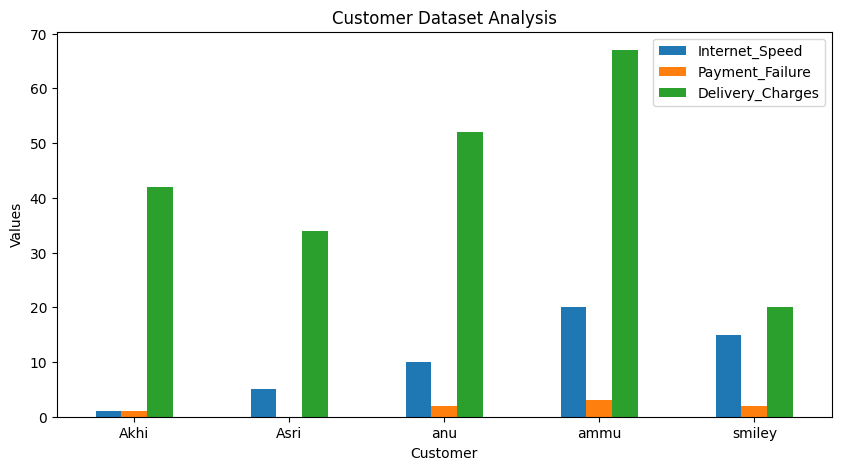

In [ ]:
df.plot(x="Customer", kind="bar", figsize=(10,5))

plt.title("Customer Dataset Analysis")
plt.ylabel("Values")
plt.xticks(rotation=0)
plt.show()

Ecommerce Dataset
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER       6.0   
1    536365     71053                  WHITE METAL LANTERN       6.0   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER       8.0   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE       6.0   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.       6.0   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  

Dataset Shape:
(12462, 8)

Column Names:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Missing V

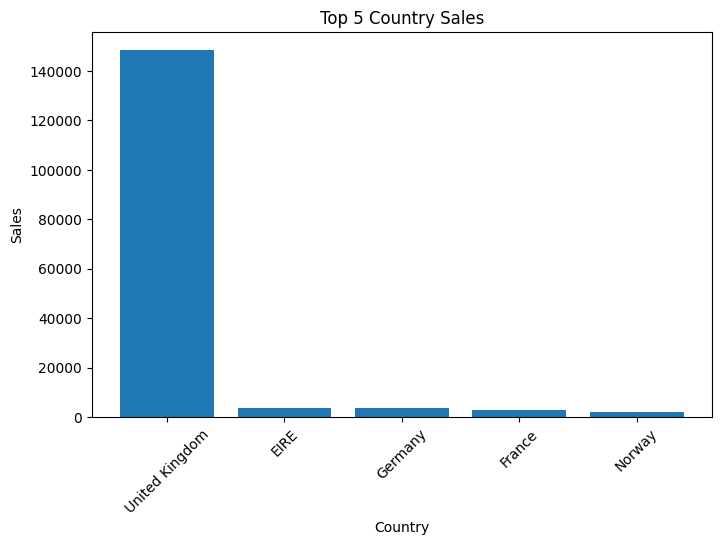

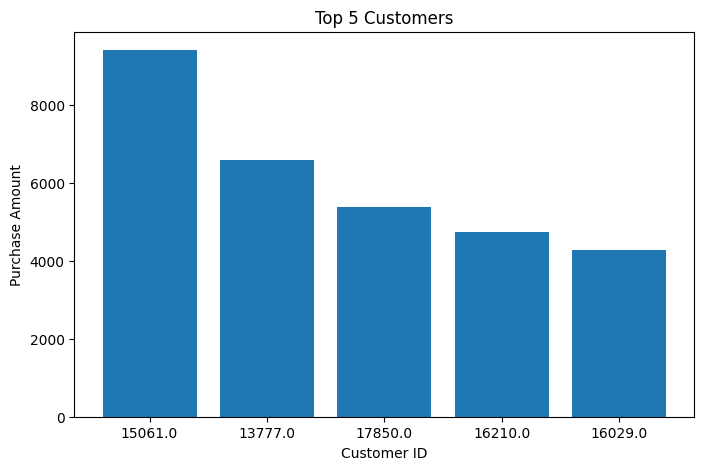

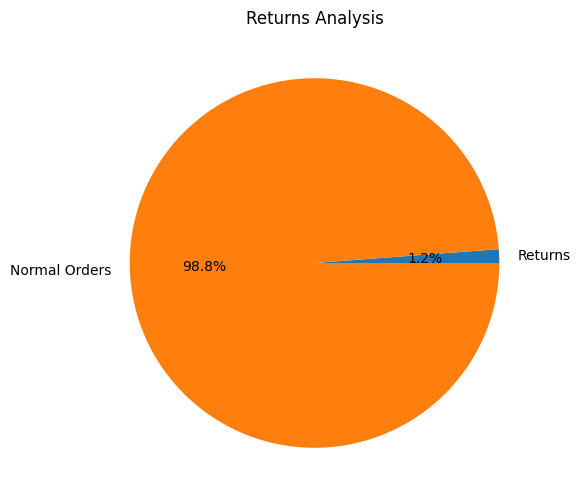

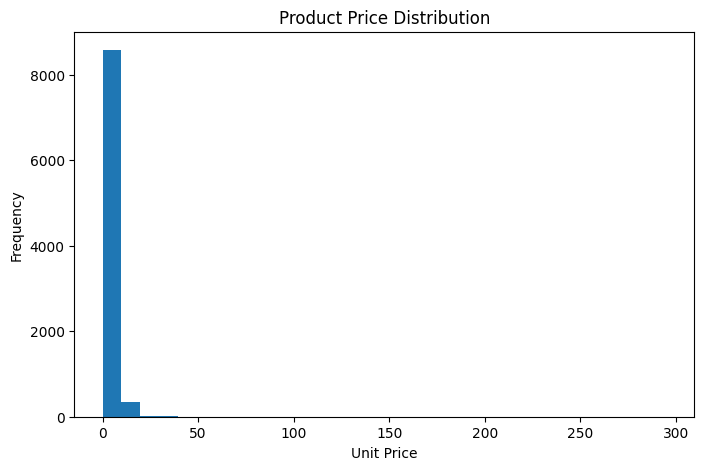

In [35]:
# ==============================
# E-COMMERCE DIAGNOSTIC ANALYSIS
# ==============================

import pandas as pd
import matplotlib.pyplot as plt

# ---------------- LOAD DATA ----------------
df = pd.read_csv("/content/ecommerce data.csv", encoding="latin1")

print("Ecommerce Dataset")
print(df.head())

# ---------------- BASIC INFORMATION ----------------
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

# ---------------- MISSING VALUES ----------------
print("\nMissing Values")
print(df.isnull().sum())

# ---------------- REMOVE MISSING CUSTOMER ID ----------------
df = df.dropna(subset=['CustomerID'])

# ---------------- CREATE TOTAL PRICE COLUMN ----------------
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# ---------------- NEGATIVE QUANTITY ANALYSIS ----------------
print("\nPRODUCT RETURN ANALYSIS")

returns = df[df['Quantity'] < 0]

print("Total Returned Orders:", len(returns))

# ---------------- HIGH PRICE PRODUCT ANALYSIS ----------------
print("\nHIGH PRICE PRODUCT ANALYSIS")

high_price = df[df['UnitPrice'] > 100]

print(high_price[['Description', 'UnitPrice']].head())

# ---------------- HIGH PURCHASE CUSTOMERS ----------------
print("\nTOP CUSTOMERS")

top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False)

print(top_customers.head())

# ---------------- COUNTRY ANALYSIS ----------------
print("\nTOP COUNTRIES")

country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

print(country_sales.head())

# ---------------- ROOT CAUSE ANALYSIS ----------------
print("\nROOT CAUSE ANALYSIS")

for i in range(len(df)):

    if df.iloc[i]['Quantity'] < 0:
        print("Return Issue:", df.iloc[i]['Description'])

    elif df.iloc[i]['UnitPrice'] > 100:
        print("High Price Issue:", df.iloc[i]['Description'])
# ---------------- ROOT CAUSE COUNT ANALYSIS ----------------

print("\nROOT CAUSE COUNT ANALYSIS")

# Count return issues
return_issue_count = len(df[df['Quantity'] < 0])

# Count high price issues
high_price_issue_count = len(df[df['UnitPrice'] > 100])

print("Total Return Issues :", return_issue_count)
print("Total High Price Issues :", high_price_issue_count)

# ==============================
# VISUALIZATIONS
# ==============================

# ---------------- TOP 5 COUNTRIES SALES ----------------
top5 = country_sales.head(5)

plt.figure(figsize=(8,5))
plt.bar(top5.index, top5.values)

plt.title("Top 5 Country Sales")
plt.xlabel("Country")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

# ---------------- TOP 5 CUSTOMERS ----------------
top5_customers = top_customers.head(5)

plt.figure(figsize=(8,5))
plt.bar(top5_customers.index.astype(str), top5_customers.values)

plt.title("Top 5 Customers")
plt.xlabel("Customer ID")
plt.ylabel("Purchase Amount")

plt.show()

# ---------------- RETURNS VS NORMAL ORDERS ----------------
return_count = len(df[df['Quantity'] < 0])
normal_count = len(df[df['Quantity'] > 0])

labels = ['Returns', 'Normal Orders']
values = [return_count, normal_count]

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%')

plt.title("Returns Analysis")

plt.show()

# ---------------- UNIT PRICE DISTRIBUTION ----------------
plt.figure(figsize=(8,5))

plt.hist(df['UnitPrice'], bins=30)

plt.title("Product Price Distribution")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.show()